In [50]:
import pandas as pd

df = pd.read_excel("ML project data.xlsx")

df.head()


,Image_ID,Category_Code,Style_Code,Season_Code,Material_Code,Price,Price_Range,Popularity,Views,Likes,Brightness,Contrast,Colorfulness,Comfort_Score,Is_Formal,Is_Casual,Is_Bright,Is_Premium,Is_Summer_Wear,Is_Winter_Wear
0,img01,1,1,0,1,45,1,78,3200,410,0.55,0.48,0.30,8,0,1,0,0,0,1
1,img02,4,2,2,1,85,2,88,5400,780,0.42,0.62,0.25,6,1,0,0,0,0,1
2,img03,3,3,1,7,95,2,82,6100,920,0.72,0.68,0.80,7,0,0,1,0,1,0
3,img04,1,4,1,1,35,1,70,2800,360,0.68,0.40,0.45,9,0,1,0,0,1,0
4,img05,2,1,0,2,50,1,75,3000,390,0.50,0.52,0.28,8,0,1,0,0,0,1


In [51]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
#we added this because it kept giving us wanring becuase jupyter running on multiple background sessions and kept giving us long popups


In [52]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Image_ID        300 non-null    object 
 1   Category_Code   300 non-null    int64  
 2   Style_Code      300 non-null    int64  
 3   Season_Code     300 non-null    int64  
 4   Material_Code   300 non-null    int64  
 5   Price           300 non-null    int64  
 6   Price_Range     300 non-null    int64  
 7   Popularity      300 non-null    int64  
 8   Views           300 non-null    int64  
 9   Likes           300 non-null    int64  
 10  Brightness      300 non-null    float64
 11  Contrast        300 non-null    float64
 12  Colorfulness    300 non-null    float64
 13  Comfort_Score   300 non-null    int64  
 14  Is_Formal       300 non-null    int64  
 15  Is_Casual       300 non-null    int64  
 16  Is_Bright       300 non-null    int64  
 17  Is_Premium      300 non-null    int

In [53]:
df_clean = df.copy()


In [54]:
x = df_clean.drop('Popularity', axis=1)
y = df_clean['Popularity']


In [55]:
x = df_clean.drop(columns=['Image_ID', 'Popularity'])
y = df_clean['Popularity']


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [57]:

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


x_train shape: (240, 18)
x_test shape: (60, 18)
y_train shape: (240,)
y_test shape: (60,)


SUPERVISED MODEL - MIDTERM MATERIAL

Linear Regression

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

lr_model = LinearRegression()

lr_model.fit(x_train, y_train)

y_pred = lr_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("mean aquared error:", mse)
print("R² score:", r2)

comparison = pd.DataFrame({
    'Actual popularity': y_test,
    'Predicted popularity': y_pred
})

comparison.head()


mean aquared error: 5.607907945155202
R² score: 0.9010194514592834


,Actual popularity,Predicted popularity
203,95,94.039118
266,92,89.719672
152,86,85.443213
9,92,92.233664
233,95,94.266720


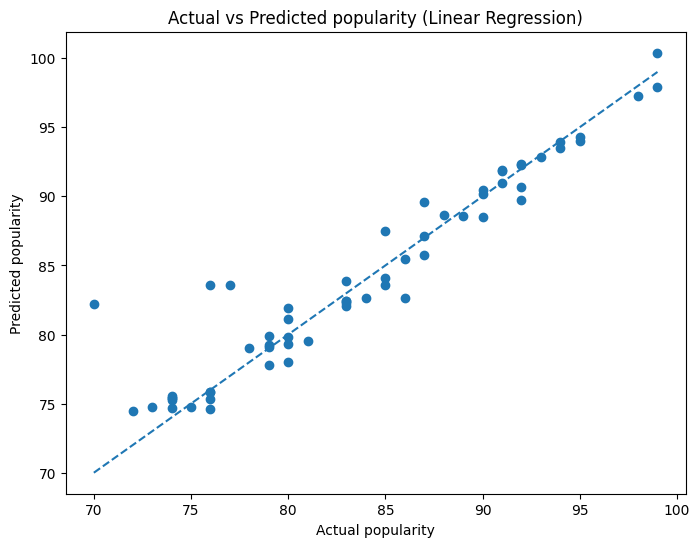

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual popularity")
plt.ylabel("Predicted popularity")
plt.title("Actual vs Predicted popularity (Linear Regression)")
plt.show()


Logistic Regression

accuracy: 0.2


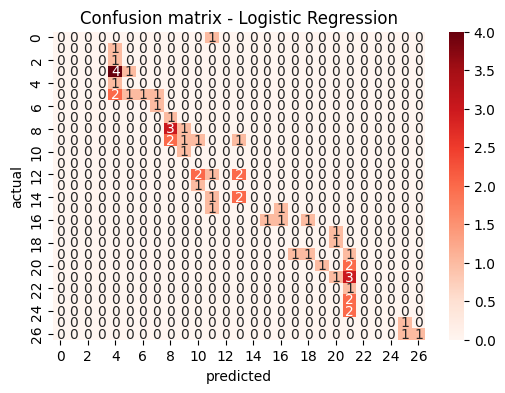

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

log_model = LogisticRegression(max_iter=3000)

log_model.fit(x_train, y_train)

y_pred = log_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("accuracy:", accuracy)



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion matrix - Logistic Regression")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()



KNN

accuracy: 0.26666666666666666


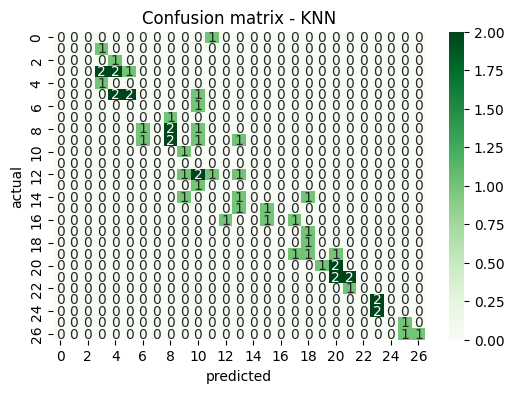

In [61]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("accuracy:", knn_accuracy)

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion matrix - KNN")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()



Decison Tree

accuracy : 0.5


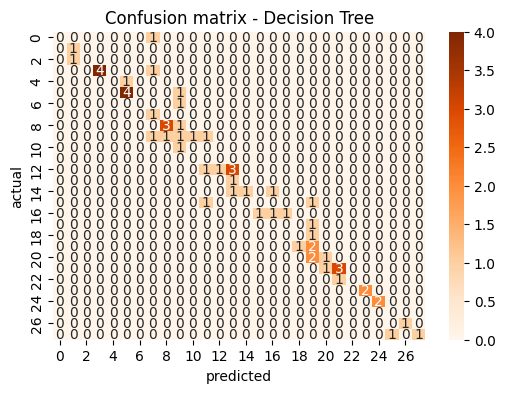

In [62]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("accuracy :", dt_accuracy)

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion matrix - Decision Tree")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()




Random Forest

accuracy: 0.6333333333333333


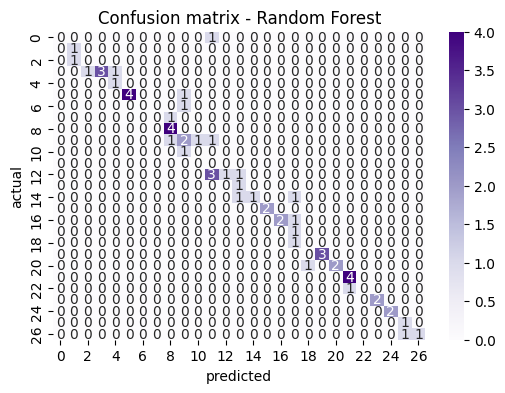

In [63]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("accuracy:", rf_accuracy)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion matrix - Random Forest")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()



Cross Validation

In [64]:
from sklearn.model_selection import cross_val_score


# Logistic Regression
log_cv_scores = cross_val_score(
    log_model,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)




# KNN
knn_cv_scores = cross_val_score(
    knn_model,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)




# Decision Tree
dt_cv_scores = cross_val_score(
    dt_model,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)



# Random Forest
rf_cv_scores = cross_val_score(
    rf_model,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)




cv_results = {
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "CV Accuracy": [
        log_cv_scores.mean(),
        knn_cv_scores.mean(),
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
}

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,Model,CV Accuracy
0,Logistic Regression,0.204167
1,KNN,0.266667
2,Decision Tree,0.487500
3,Random Forest,0.487500


UNSUPERVISED MODELS

K Means

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [66]:
x_kmeans = df_clean[['Price', 'Brightness', 'Colorfulness', 'Comfort_Score', 'Views', 'Likes']]

In [67]:
scaler_km = StandardScaler()
x_kmeans_scaled = scaler_km.fit_transform(x_kmeans)

In [68]:
x_kmeans_scaled[:5]

array([[-0.65330087, -0.03660303, -0.52770181,  0.51782704, -0.90497695,
        -0.88112002],
       [-0.26823233, -0.92326031, -0.72081055, -1.37666212,  0.01619021,
        -0.10440209],
       [-0.17196519,  1.12287187,  1.40338557, -0.42941754,  0.30928885,
         0.18949119],
       [-0.749568  ,  0.85005424,  0.0516244 ,  1.46507162, -1.07246189,
        -0.9860819 ],
       [-0.6051673 , -0.37762506, -0.60494531,  0.51782704, -0.98871942,
        -0.92310477]])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

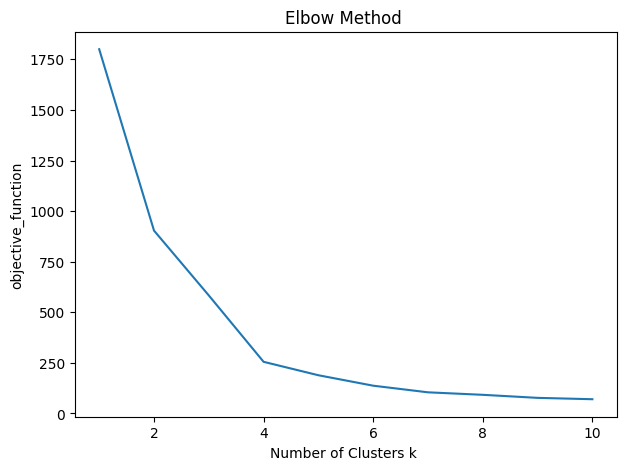

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [86]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_kmeans_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_range, inertia)

plt.xlabel("Number of Clusters k ")
plt.ylabel("objective_function")
plt.title("Elbow Method ")
plt.show()


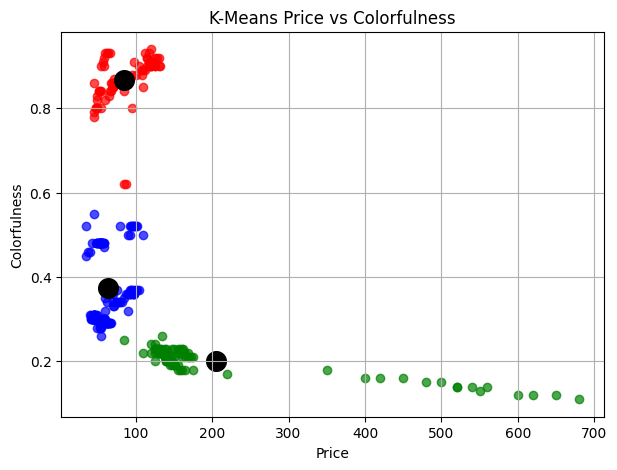

In [70]:
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(x_kmeans_scaled)


df_clean['Cluster'] = kmeans_model.labels_


df_clean[['Price', 'Colorfulness', 'Views', 'Popularity', 'Cluster']].head()


cluster_colors = {0: 'blue', 1: 'green', 2: 'red'}

plt.figure(figsize=(7,5))

for cluster_id in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['Price'],
        cluster_data['Colorfulness'],
        color=cluster_colors[cluster_id],
        alpha=0.7
    )


centroids = scaler_km.inverse_transform(kmeans_model.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 2],
    c='black',
    marker='o',
    s=200,
    label='Centroids'
)

plt.xlabel("price")
plt.ylabel("colorfulness")
plt.title("K-Means Price vs colorfulness")
plt.grid(True)
plt.show()


PCA

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [72]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_kmeans)

In [73]:
x_scaled[:5]
pca = PCA()
pca.fit(x_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

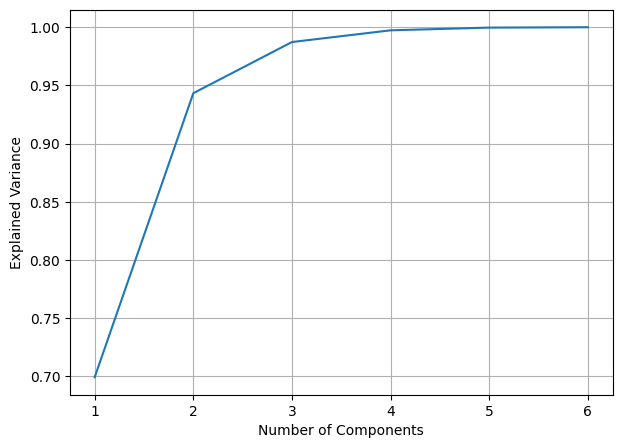

In [75]:


plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.grid(True)
plt.show()


Variance kept (2D): 0.9433088738123165


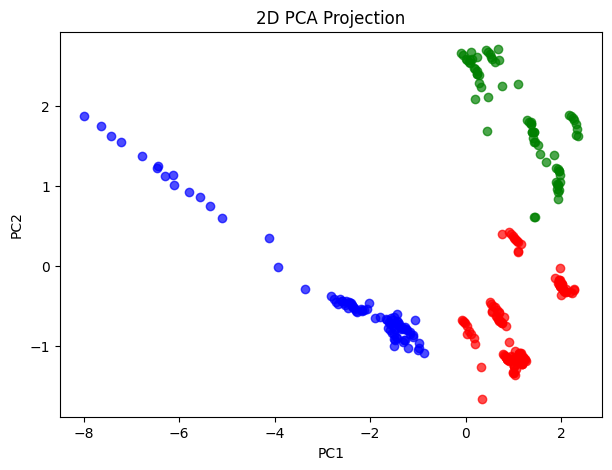

In [76]:
pca_2 = PCA(n_components=2)
x_pca_2d = pca_2.fit_transform(x_scaled)

print("Variance kept (2D):", pca_2.explained_variance_ratio_.sum())

colors = ['red', 'blue', 'green', 'purple']

plt.figure(figsize=(7,5))

for i, cluster in enumerate(sorted(df_clean['Cluster'].unique())):
    points = x_pca_2d[df_clean['Cluster'] == cluster]
    plt.scatter(points[:,0], points[:,1], color=colors[i], alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()


Variance kept (3D): 0.9872726789909502


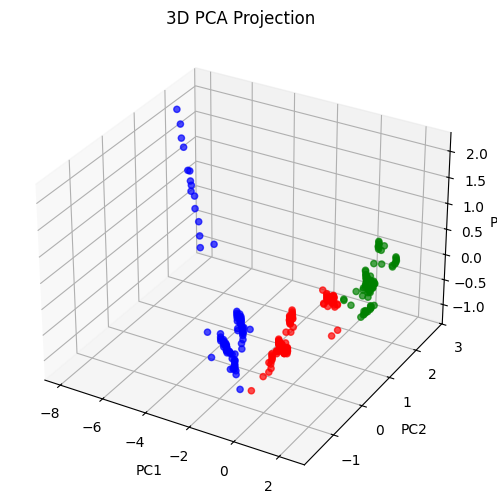

In [77]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)
x_pca_3d = pca_3.fit_transform(x_scaled)

print("Variance kept (3D):", pca_3.explained_variance_ratio_.sum())

colors = ['red', 'blue', 'green', 'purple']

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i, cluster in enumerate(sorted(df_clean['Cluster'].unique())):
    points = x_pca_3d[df_clean['Cluster'] == cluster]
    ax.scatter(points[:,0], points[:,1], points[:,2], color=colors[i], alpha=0.7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
plt.show()


**Apriori**

In [78]:
apriori_data = df_clean[
    [
        'Is_Formal',
        'Is_Casual',
        'Is_Bright',
        'Is_Premium',
        'Is_Summer_Wear',
        'Is_Winter_Wear'
    ]
]

apriori_data.head()


,Is_Formal,Is_Casual,Is_Bright,Is_Premium,Is_Summer_Wear,Is_Winter_Wear
0,0,1,0,0,0,1
1,1,0,0,0,0,1
2,0,0,1,0,1,0
3,0,1,0,0,1,0
4,0,1,0,0,0,1


In [79]:
apriori_data_bool = apriori_data.astype(bool)
apriori_data_bool.head()


,Is_Formal,Is_Casual,Is_Bright,Is_Premium,Is_Summer_Wear,Is_Winter_Wear
0,False,True,False,False,False,True
1,True,False,False,False,False,True
2,False,False,True,False,True,False
3,False,True,False,False,True,False
4,False,True,False,False,False,True


In [80]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    apriori_data_bool,
    min_support=0.1,
    use_colnames=True
)

frequent_itemsets


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.240000,(Is_Formal)
1,0.493333,(Is_Casual)
2,0.233333,(Is_Bright)
3,0.346667,(Is_Summer_Wear)
4,0.653333,(Is_Winter_Wear)
5,0.240000,"(Is_Formal, Is_Winter_Wear)"
6,0.170000,"(Is_Summer_Wear, Is_Casual)"
7,0.323333,"(Is_Winter_Wear, Is_Casual)"
8,0.196667,"(Is_Bright, Is_Summer_Wear)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [81]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,(Is_Formal),(Is_Winter_Wear),0.240000,1.000000,1.530612
1,(Is_Winter_Wear),(Is_Formal),0.240000,0.367347,1.530612
2,(Is_Winter_Wear),(Is_Casual),0.323333,0.494898,1.003172
3,(Is_Casual),(Is_Winter_Wear),0.323333,0.655405,1.003172
4,(Is_Bright),(Is_Summer_Wear),0.196667,0.842857,2.431319
5,(Is_Summer_Wear),(Is_Bright),0.196667,0.567308,2.431319


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [82]:
top_rules = rules.sort_values(by='lift', ascending=False).head(10)
top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
4,(Is_Bright),(Is_Summer_Wear),0.196667,0.842857,2.431319
5,(Is_Summer_Wear),(Is_Bright),0.196667,0.567308,2.431319
1,(Is_Winter_Wear),(Is_Formal),0.240000,0.367347,1.530612
0,(Is_Formal),(Is_Winter_Wear),0.240000,1.000000,1.530612
3,(Is_Casual),(Is_Winter_Wear),0.323333,0.655405,1.003172
2,(Is_Winter_Wear),(Is_Casual),0.323333,0.494898,1.003172


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [83]:
def print_fashion_rules(rules_df, num_rules=5):
    print(f"\n--- Top {num_rules} Fashion Association Rules ---\n")

    top_sorted = rules_df.sort_values(by='lift', ascending=False).head(num_rules)

    for i, row in top_sorted.iterrows():
        antecedents = list(row['antecedents'])
        consequents = list(row['consequents'])

        print(f"Rule {i}:")
        print(f"IF the outfit is: {antecedents}")
        print(f"THEN it is also likely: {consequents}")
        print(f"Confidence: {row['confidence']:.0%}")
        print(f"Lift: {row['lift']:.2f}")
        print("-" * 50)

print_fashion_rules(rules)



--- Top 5 Fashion Association Rules ---

Rule 4:
IF the outfit is: ['Is_Bright']
THEN it is also likely: ['Is_Summer_Wear']
Confidence: 84%
Lift: 2.43
--------------------------------------------------
Rule 5:
IF the outfit is: ['Is_Summer_Wear']
THEN it is also likely: ['Is_Bright']
Confidence: 57%
Lift: 2.43
--------------------------------------------------
Rule 1:
IF the outfit is: ['Is_Winter_Wear']
THEN it is also likely: ['Is_Formal']
Confidence: 37%
Lift: 1.53
--------------------------------------------------
Rule 0:
IF the outfit is: ['Is_Formal']
THEN it is also likely: ['Is_Winter_Wear']
Confidence: 100%
Lift: 1.53
--------------------------------------------------
Rule 3:
IF the outfit is: ['Is_Casual']
THEN it is also likely: ['Is_Winter_Wear']
Confidence: 66%
Lift: 1.00
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag